<table border=0 width="100%"><tr><td><p align="left"><img src="../img/logo.png" align="left" width=300></p></td><td><font size=5><B></B></font>用numpy和pandas做数据预处理（郑海超）</td></tr></table>

# 内容
- numpy数组和list的区别
- numpy数组基础操作:以Titanic为例
- numpy数组基础操作:以图片翻转为例
- pandas基础：以股吧数据预处理与可视化为例

# 上周课后作业分享

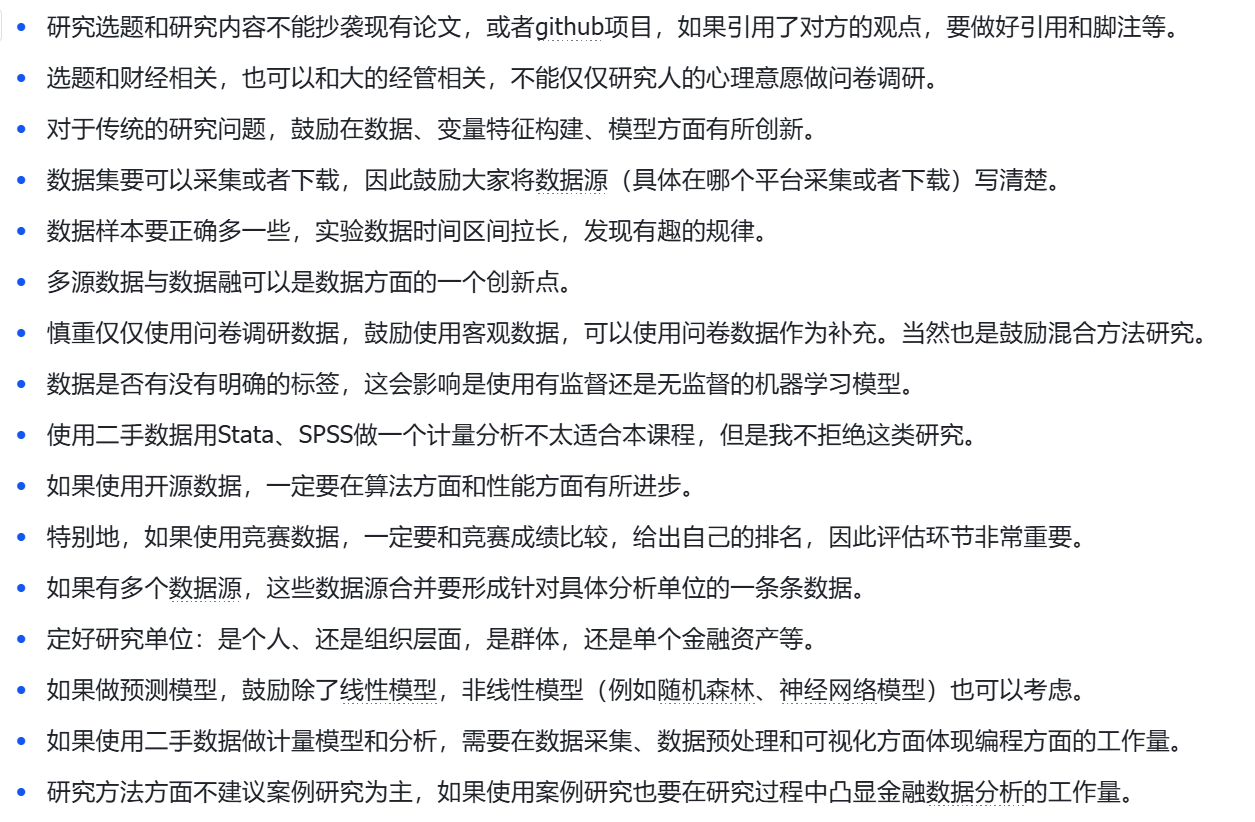

# 大脑的可塑性与自我调控能力的重要性

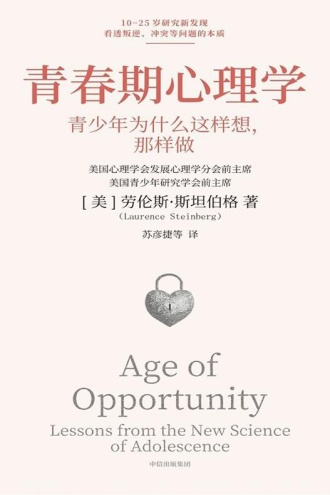

# numpy数组和list的区别

**NumPy（Numerical Python的简称）**是Python数值计算最重要的基础包。大多数提供科学计算的包都是用NumPy的数组作为构建基础。

NumPy的部分功能如下:
* ndarray，一个具有矢量算术运算和复杂***广播***能力的快速且节省空间的<font color=blue>多维数组</font>。
* 用于对***整组数据***进行快速运算的标准数学函数（无需编写循环）。
* 线性代数、随机数生成以及傅里叶变换功能。
* 用于集成由C、C++、Fortran等语言编写的代码的API。

NumPy对于数值计算特别重要的原因之一，是因为它可以***高效处理大数组的数据***。这是因为：
* NumPy是在一个连续的内存块中存储数据，独立于其他Python内置对象。NumPy的C语言编写的算法库可以操作内存，而不必进行类型检查或其它前期工作。比起Python的内置序列，NumPy数组使用的内存更少。
* NumPy可以在整个数组上执行复杂的计算，而***不需要Python的for循环***。

在实现层面，数组本质上包含一个指向一个连续数据块的指针。而Python列表包含一个指向指针块的指针，每个指针又指向一个完整的Python对象。如下图所示：

<img src="../img/array.png" align='left' height="350" width="400"/>

In [2]:
# 考察一个包含一百万整数的数组，和一个等价的Python列表：
import numpy as np
my_arr = np.arange(1000000)
my_list = list(range(1000000))      

魔法命令
- %time
- %%time

In [6]:
# 计时 %time
%time for _ in range(10): my_arr2 = my_arr * 2 # 每个元素乘以2

CPU times: total: 15.6 ms
Wall time: 16.3 ms


1s = 1000ms

CPU time：衡量的是CPU用来执行程序的时间；

Wall time：从计算开始到计算结束等待的时间。

**如何对列表的每个元素乘以2？**

In [ ]:
# my_list * 2是什么操作？
my_list * 2

In [9]:
%time for _ in range(10): my_list2 = [x * 2 for x in my_list] # 列表每个元素乘以2


CPU times: total: 562 ms
Wall time: 621 ms


**大家可以调整一下数组或者列表的长度体验一下二者的差异**

# numpy数组基础操作:以Titanic为例

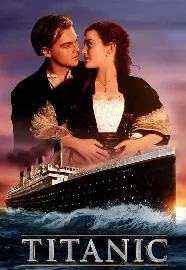

### 导入数据并探索数据属性

the columns of titanic.csv

| index | column name |
| ------ | ------ | 
| 0 | Survived | 
| 1 | Pclass | 
| 2 | Name | 
| 3 | Sex | 
| 4 | Age | 
| 5 | Siblings | 
| 6 | Parents | 
| 7 | Fare |  

[Kaggle](https://www.kaggle.com/c/titanic/data)

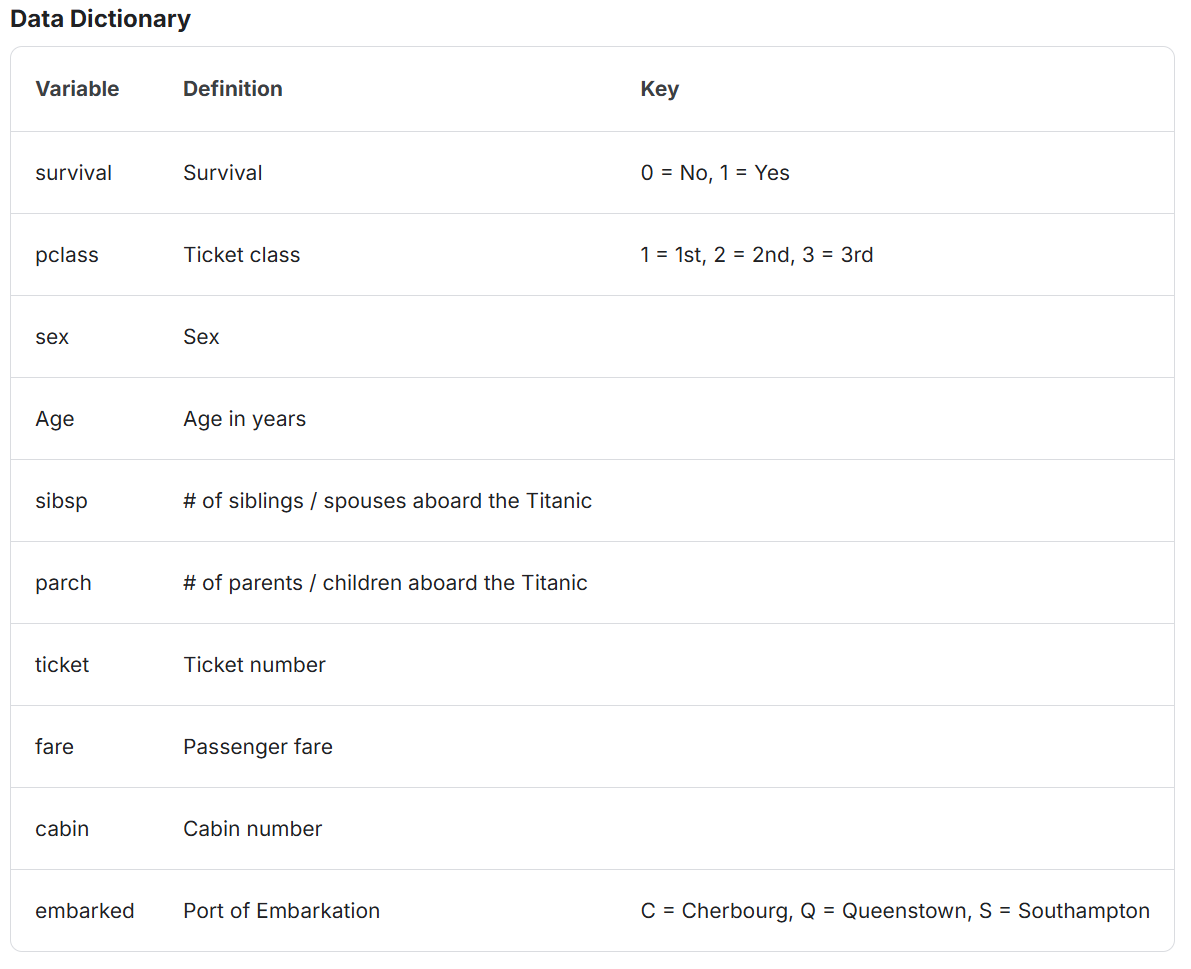

In [17]:
# read numpy from csv file
titanic = "titanic.csv"
titanic_data = np.loadtxt(titanic,delimiter=",",skiprows= 1,dtype=str)
# titanic_data = np.loadtxt(titanic,delimiter=",",skiprows= 1,usecols=(0,1,3,4,7),dtype=str)

Q1: how many passengers in the ship?

Q2: what is the data type of the dataset?

Q3: how many entries in the dataset?

Q4: how many dimensions of the array?

Q5: what is the ratios of the survivors and the non-survivors for women and men?


In [26]:
# how many passengers in the ship from the data of titanic_data?
total_passengers = len(titanic_data)
print(f"Q1: 船上共有 {total_passengers} 名乘客")


Q1: 船上共有 887 名乘客


In [37]:
# what is the data type of the dataset?
data_types = titanic_data.dtype
print("Q2: 数据集的数据类型:")
print(data_types)

Q2: 数据集的数据类型:
<U81


dtype('<U81') 是 pandas 中的 Unicode字符串数据类型 。

In [34]:
# how many entries in the dataset? (size)
num_entries = len(titanic_data)
print(f"Q3: 数据集中共有 {num_entries} 个条目")



Q3: 数据集中共有 887 个条目


In [21]:
887*8

7096

In [38]:
# how many dimensions of the array?(ndim)

dimensions = titanic_data.ndim
print(f"Q4: 数组有 {dimensions} 维")
print(f"数组形状: {titanic_data.shape}")


Q4: 数组有 2 维
数组形状: (887, 8)


### 探索问题：泰坦尼克号乘客的生还率的性别差异

In [70]:
# the first row of that dataset titanic_data[0:1,:]
titanic_data[0:1,:]


array([['0', '3', 'Mr. Owen Harris Braund', 'male', '22', '1', '0',
        '7.25']], dtype='<U81')

can we use titanic_data[0,:]?

In [71]:
# the first row of that dataset
titanic_data[0:1,:]


array([['0', '3', 'Mr. Owen Harris Braund', 'male', '22', '1', '0',
        '7.25']], dtype='<U81')

**观察：上述切片方法的结果有什么差异？**




In [ ]:
# the first column of titanic_data
titanic_data[:,0:1].shape

Object `shape` not found.


In [47]:
# the first element
titanic_data[0,0]

'0'

In [48]:
# 应用numpy布尔运算，判断性别是否为女性：titanic_data[:,3] =="female"
b_female = titanic_data[:,3] == "female"
titanic_data[b_female].shape


(314, 8)

In [53]:
# the sex column
female_bool = (titanic_data[:,3] =="female")
male_bool =  (titanic_data[:,3] =="male")

In [51]:
# the count of men
len(titanic_data[male_bool])


573

In [ ]:
# the count of female
len(titanic_data[female_bool])

314

In [62]:
# slice man and woman （boolean index）
man = titanic_data[male_bool]

woman = titanic_data[female_bool]


In [63]:
man_f= man[:,[0,1,4,5,6,7]] # remove the sex column, you can also try function np.delete()
man_f

array([['0', '3', '22', '1', '0', '7.25'],
       ['0', '3', '35', '0', '0', '8.05'],
       ['0', '3', '27', '0', '0', '8.4583'],
       ...,
       ['0', '2', '27', '0', '0', '13'],
       ['1', '1', '26', '0', '0', '30'],
       ['0', '3', '32', '0', '0', '7.75']], dtype='<U81')

In [69]:
# 计算男性生存的比率
man_f= man_f.astype( "float32" ) # change the data type
man_f[:,0].mean()




0.19022688

In [68]:
# 计算女性生存的比率（切片第一列，然后求出均值）
woman_f = woman[:,[0,1,4,5,6,7]]
woman_f = woman_f.astype( "float32" ) # change the data type
np.mean(woman_f[:,0])



0.7420382

### numpy数组相乘

## np.dot

这种运算在机器学习的数据转换中很常用，例如神经网络的全连接网络。

<img src="../img/dot.png" align='left' height="300" width="400"/>

In [74]:
# np.dot
a = np.array([1,1,1])
b = np.array([1,2,3])

print(a * b)

print(np.dot(a,b))


[1 2 3]
6


In [75]:
x = np.array([1,2])
W = np.array([[1,3,5],
             [2,4,6]])
print(x.shape)
print(W.shape)
print(np.dot(x,W))

(2,)
(2, 3)
[ 5 11 17]


In [76]:
x = np.array([[1,2],
              [1,1]])
W = np.array([[1,3,5],
             [2,4,6]])
print(x.shape)
print(W.shape)
print(np.dot(x,W))

(2, 2)
(2, 3)
[[ 5 11 17]
 [ 3  7 11]]


## 矩阵乘法和神经元网络构造

https://zh.d2l.ai/chapter_multilayer-perceptrons/mlp.html

一个单隐藏层的多层感知机，具有5个隐藏单元
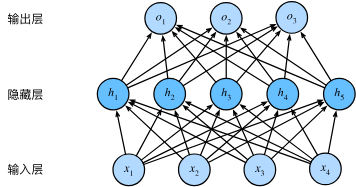

下面是一个更简单的神经网络，没有任何中间层（隐藏层）

<img src="../img/matrix_multiply.png" align='left'/>

Matrix multiplication is often used in the linear transformation step. Let's say we have an input vector x of size n, and we want to transform it using a weight matrix W of size m x n, where m is the number of neurons in the current layer. We can do this by computing the dot product of the weight matrix and the input vector:

z = Wx

This gives us a new vector z of size m. We can then apply an activation function to z to get the output of the current layer. For example, if we use the ReLU activation function, the output y would be:

y = max(0, z) （在神经网络中，我们会将z称为神经元的输出，将y称为神经元的激活值）

In [77]:
import numpy as np

# Define the input vector and weight matrix
x = np.array([1, -2, 3])
W = np.array([[0.1, 0.2, 0.3], [0.4, -0.5, 0.6], [-0.7, -0.8, 0.9], [1.0, -1.1, -1.2]])

# Compute the dot product to get the output vector
z = np.dot(W, x)

z


array([ 0.6,  3.2,  3.6, -0.4])

In [78]:
# Apply the ReLU activation function to the output vector
y = np.maximum(0, z)

Questions: explain the code above, and how it performs the feedforward process in a neural network.

tips: compute that transformaiton by hand

# numpy数组基础操作:以图形变形为例

(357, 357, 3)
<class 'numpy.ndarray'>


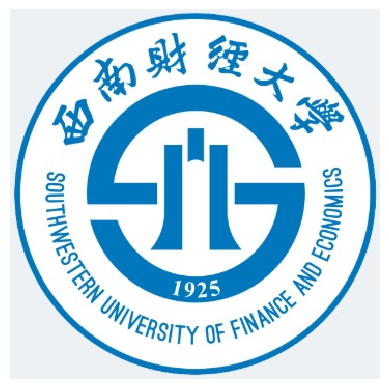

In [79]:
import numpy as np
import matplotlib.pylab as plt

def plti(im, **kwargs):
    """
    画图的辅助函数
    """
    plt.imshow(im, interpolation="none", **kwargs)
    plt.axis('off') # 去掉坐标轴
    plt.show() # 弹窗显示图像


# 加载图像
im = plt.imread("swufeLogo.png") # 加载图片
print(im.shape) # 输出图像尺寸
print(type(im))
plti(im)

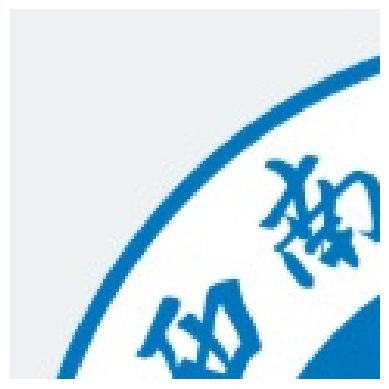

In [98]:
# 剪切图片(左上角)
plti(im[:119,:119,:])




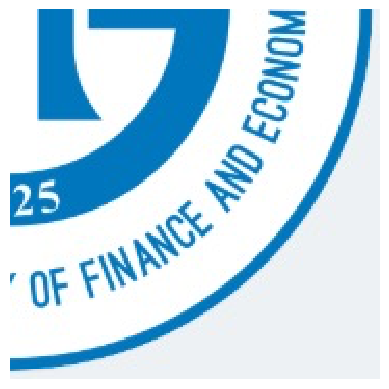

In [97]:
# 剪切图片(右下角)
plti(im[179:,179:,:])


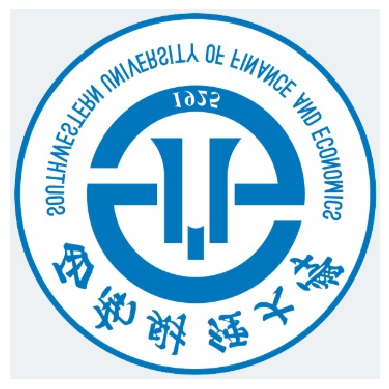

In [96]:
# 图片上下翻转(调整步长试试呢)
plti(im[::-1,::1,:])


# 序列：Series

Tables are a fundamental object type for representing data sets. A table can be viewed in two ways:
* a sequence of named columns that each describe a single aspect of all entries in a data set, or
* a sequence of rows that each contain all information about a single entry in a data set.

see the table of [titantic](titanic.csv)

## create Series
A Series is a one-dimensional labeled array with axis labels in pandas. It can be created in a few ways:

In [84]:
# Creating a Series from a List:
import pandas as pd

my_list = [10, 20, 30, 40, 50]
series = pd.Series(my_list)
print(series)

0    10
1    20
2    30
3    40
4    50
dtype: int64


In [ ]:
#get the index of the series

In [99]:
# Using index initialization:
s = pd.Series(data=[1, 2, 3,4], index=['a', 'b', 'c', 'a'])
s

a    1
b    2
c    3
a    4
dtype: int64

In [86]:
# create your own index
import pandas as pd
s = pd.Series(data=['one', 'two', 'three', 'four'], index=range(1,5))
s

1      one
2      two
3    three
4     four
dtype: object

In [87]:
# Creating a Series from a Dictionary:
import pandas as pd

my_dict = {'a': 10, 'b': 20, 'c': 30, 'd': 40, 'e': 50, 'a':20}
print(my_dict)
series = pd.Series(my_dict)
print(series)

{'a': 20, 'b': 20, 'c': 30, 'd': 40, 'e': 50}
a    20
b    20
c    30
d    40
e    50
dtype: int64


In [88]:
# Creating a Series from a NumPy array:
import numpy as np
import pandas as pd

my_array = np.array([10, 20, 30, 40, 50])
series = pd.Series(my_array)
print(series)

0    10
1    20
2    30
3    40
4    50
dtype: int32


In [100]:
# creat a time series using numpy and date_index
import numpy as np
import pandas as pd

# Create a NumPy array with 100 random values
my_array = np.random.randn(100)

# Create a DatetimeIndex with 100 consecutive dates starting from 2022-01-01
date_index = pd.date_range('2025-01-01', periods=100, freq='D')
print(type(date_index))
# Create a Pandas Series using the NumPy array as the data and the DatetimeIndex as the index
series = pd.Series(my_array, index=date_index)

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


## userful operations on numerical series

Some useful methods on Series include:
- s.values - Get the values array
- s.index - Get the index
- s.head() - Get the first 5 rows
- s.tail() - Get the last 5 rows
- s.iloc[1] - Get label-based value
- s.loc['a'] - Get integer position based value 
- s.sum() - Sum of values
- s.mean() - Mean of values
- s.std() - Standard deviation
- s.min() - Minimum value
- s.max() - Maximum value
- s.append(other_series) - Append another Series 
- s. groupby(some_index).sum() - Group by index and sum
- s.sort_values() - Sort series by values
- s.sort_index() - Sort series by index 
- s.rename(index={old_name: new_name}) - Rename index

In [101]:
# I will show soem examples for iloc and loc
import pandas as pd

# Create a Pandas Series with some random values
my_series = pd.Series([10, 20, 30, 40, 50], index=['a', 'b', 'c', 'd', 'e'])

# Access an element using iloc
print(my_series.loc["b":"e"])   

b    20
c    30
d    40
e    50
dtype: int64


In [ ]:
# this is python script using loc
import pandas as pd

# Create a Pandas Series with some random values
my_series = pd.Series([10, 20, 30, 40, 50], index=['a', 'b', 'c', 'd', 'e'])

# Access an element using loc: b


# Access a slice of elements using loc




In [ ]:
# Access a slice of elements using iloc
my_series




## useful operations on text Series

In [ ]:
comments = ["继续加仓了，就当存银行定期吧[摊手][摊手][摊手]继续加仓了，就当存银行定期吧",
           "这厮已经回到年初大盘两千五百点左右的价位了",
           "跌破8块可以抄底了跌破8块可以抄底了"]

series_comments = pd.Series(comments)
series_comments

In [ ]:
# boolean切片
b = series_comments.str.contains("加仓")




In [ ]:
# 获取每个字符串的长度
series_comments




A list of common operations on text Series in pandas:
- str.lower() - Convert strings to lowercase
- str.upper() - Convert strings to uppercase 
- str.title() - Capitalize first letters of strings
- str.split() - Split strings on delimiter 
- str.contains() - Check if string contains substring
- str.replace() - Replace occurrences of substring
- str.len() - Get length of each string
- str.strip() - Remove leading and trailing whitespace 
- str.lstrip() - Remove leading whitespace
- str.rstrip() - Remove trailing whitespace
- str.startswith() - Check if strings start with substring 
- str.endswith() - Check if strings end with substring
- str.find() - Find position of substring 
- str.rfind() - Find last position of substring 
- str.count() - Count occurrences of substring   
- str.cat() - Concatenate strings 
- str.repeat() - Repeat values 
- str.pad() - Pad strings 
- str.center() - Center strings 
- str.slice() - Slice strings 
- str.slice_replace() - Replace slice in strings 
- str.wrap() - Wrap strings into multiple lines 
- str.get() - Extract element from strings
- str.join() - Join strings in Series using delimiter 
- str.match() - Extract capture groups in strings  
- str.extract() - Extract capture groups from strings 

# 使用pandas预处理数据：以股吧数据预处理为例

## 构建dataframe

In [104]:
import pandas as pd

# 创建多个Series
series1 = pd.Series([1, 2, 3, 4])
series2 = pd.Series([5, 6, 7, 8])
series3 = pd.Series([9, 10, 11, 12])

# 使用序列构建dataframe
df = pd.DataFrame({"A_col":series1,"B_col": series2, "C_col":series3})

df

,A_col,B_col,C_col
0,1,5,9
1,2,6,10
2,3,7,11
3,4,8,12


## task
预处理东方财富股吧中[光线传媒相关的评论](http://guba.eastmoney.com/list,300251.html)。股评数据保存在data文件夹,数据文件是300251.csv。主要工作包括：
* 读取数据
* 修改数据类型
* 删除不需要的列
* 删除光线传媒发布的文章 

数据清洗是数据分析第一步重要工作，特别是我们从网络抓取的数据，更是需要特别谨慎。如果输入的是垃圾，那么得到的也是垃圾。作为数据分析人员，我们一定要敢于跳进数据中，干一些数据清洗的脏活累活。

<img src="../img/garbage_in.jpg" align='left' height="200" width="300"/>
<img src="../img/cleaning.png" align='left' height="300" width="400"/>

## read data from csv

- encoding
- names=["date","author","url","comment"]

In [105]:
import pandas as pd
comments = pd.read_csv("300251.csv", encoding="gbk", names = ["date","author","url","comment"])
comments.columns

Index(['date', 'author', 'url', 'comment'], dtype='object')

In [111]:
comments.shape

(129856, 4)

In [106]:
comments.head()

,date,author,url,comment
0,2019-03-25 16:13:22,光线传媒资讯,"http://guba.eastmoney.com/news,300251,81164281...",\r\n 光线传媒:关...
1,2019-03-26 15:47:21,恭喜发财红利就来,"http://guba.eastmoney.com/news,300251,81192614...",\r\n 各位兄弟，再...
2,2019-03-26 16:18:41,老老老老老康,"http://guba.eastmoney.com/news,300251,81193282...",\r\n 继续加仓了，...
3,2019-03-26 17:04:14,说你点啥好呢,"http://guba.eastmoney.com/news,300251,81194240...",\r\n 跌破8块可以...
4,2019-03-26 17:30:25,资金解密,"http://guba.eastmoney.com/news,300251,81194742...",\r\n 光线传媒03...


In [108]:
# 有多少独立的作者:unique()
len(comments["author"].unique())

20528

## data type conversion

In [109]:
comments.dtypes

date       object
author     object
url        object
comment    object
dtype: object

In [110]:
comments.head()

,date,author,url,comment
0,2019-03-25 16:13:22,光线传媒资讯,"http://guba.eastmoney.com/news,300251,81164281...",\r\n 光线传媒:关...
1,2019-03-26 15:47:21,恭喜发财红利就来,"http://guba.eastmoney.com/news,300251,81192614...",\r\n 各位兄弟，再...
2,2019-03-26 16:18:41,老老老老老康,"http://guba.eastmoney.com/news,300251,81193282...",\r\n 继续加仓了，...
3,2019-03-26 17:04:14,说你点啥好呢,"http://guba.eastmoney.com/news,300251,81194240...",\r\n 跌破8块可以...
4,2019-03-26 17:30:25,资金解密,"http://guba.eastmoney.com/news,300251,81194742...",\r\n 光线传媒03...


In [112]:
comments["date"] = pd.to_datetime(comments.date)

In [ ]:
# check the data types of the columns again




astype method

To convert data types in Pandas, you can also use the astype() method, which allows you to convert a column or multiple columns to a specified data type. Here's an example of how to convert a column to a specific data type:

In [113]:
import pandas as pd

# create a sample dataframe
data = {'name': ['John', 'Mary', 'Jane', 'James'],
        'age': [28.0, 32.0, 19.0, 45.0],
        'income': [45000, 65000, 22000, 89000]}
df = pd.DataFrame(data)

df.head()

,name,age,income
0,John,28.0,45000
1,Mary,32.0,65000
2,Jane,19.0,22000
3,James,45.0,89000


In [114]:
df.dtypes

name       object
age       float64
income      int64
dtype: object

In [ ]:
# convert the 'age' column to int




In [ ]:
# convert the 'income' column to float





##  sort_values

In [116]:
# 对comments按日期排序，不用inplace=True， 不需要ascending=False
comments = comments.sort_values(by="date")
comments

,date,author,url,comment
107189,2011-07-14 21:30:36,NaN,"http://guba.eastmoney.com/news,300251,41042328...",\r\n 88888\...
77669,2011-07-14 21:31:46,NaN,"http://guba.eastmoney.com/news,300251,41042370...",\r\n 发行价30块...
107188,2011-07-14 21:33:20,NaN,"http://guba.eastmoney.com/news,300251,41042422...",\r\n 3\r\n ...
129105,2011-07-14 22:01:26,更深的蓝888,"http://guba.eastmoney.com/news,300251,41043504...",\r\n 好股，拿住！...
107192,2011-07-14 22:20:38,NaN,"http://guba.eastmoney.com/news,300251,41044269...",\r\n 应收账款与日...
...,...,...,...,...
1089,2019-04-10 14:59:03,不能满仓,"http://guba.eastmoney.com/news,300251,81539067...",\r\n 大家要坚信，...
2779,2019-04-10 15:00:48,财经评论,"http://guba.eastmoney.com/news,cjpl,815391292....",\r\n A股三大股指...
1119,2019-04-10 15:00:48,财经评论,"http://guba.eastmoney.com/news,cjpl,815391292....",\r\n A股三大股指...
2770,2019-04-10 16:28:13,光线传媒资讯,"http://guba.eastmoney.com/news,300251,81541483...",\r\n 光线传媒：一...


## drop column of url

- axis = 0表示沿着每一列或行标签\索引值向下执行
- axis = 1表示沿着每一行或者列标签横向执行对应

In [117]:
# drop column url from comments
comments = comments.drop(columns=["url"])
comments


,date,author,comment
107189,2011-07-14 21:30:36,NaN,\r\n 88888\...
77669,2011-07-14 21:31:46,NaN,\r\n 发行价30块...
107188,2011-07-14 21:33:20,NaN,\r\n 3\r\n ...
129105,2011-07-14 22:01:26,更深的蓝888,\r\n 好股，拿住！...
107192,2011-07-14 22:20:38,NaN,\r\n 应收账款与日...
...,...,...,...
1089,2019-04-10 14:59:03,不能满仓,\r\n 大家要坚信，...
2779,2019-04-10 15:00:48,财经评论,\r\n A股三大股指...
1119,2019-04-10 15:00:48,财经评论,\r\n A股三大股指...
2770,2019-04-10 16:28:13,光线传媒资讯,\r\n 光线传媒：一...


## delete the comments posted by 光线传媒资讯

光线传媒公告和其他的财经评论的数据对于投资人决策也很重要，我们着重分析投资人评论对股价波动的影响，为了减少公司公告的影响，在此去掉了公司公告。如果要研究公司公告，需要特别分析公告的内容。

思考：如何删除“author”是 “光线传媒资讯”的评论呢？，提示可以使用切片

In [118]:
# 查看一下comments中帖子作者author列的分布：使用value_counts()方法
comments["author"].value_counts()


author
光线传媒资讯         3782
可乐与白开水5783     2020
股神9818          519
hhl10160012     511
锅包肉1979         477
               ... 
苏E52X23           1
一米漂泊              1
高师傅2              1
妖年2016            1
京ZL8544           1
Name: count, Length: 20527, dtype: int64

In [121]:
# 使用布尔型切片方法，删除comments中author列值为'光线传媒资讯'的行
# 布尔型切片方法：comments[条件]
# 条件：comments.author != '光线传媒资讯'
# 结果：返回一个布尔型数组，数组元素为True表示对应行的author列值不为'光线传媒资讯'，为False表示对应行的author列值为'光线传媒资讯'
comments.author != '光线传媒资讯'
comments = comments[comments.author != '光线传媒资讯']

In [125]:
# 使用布尔型切片方法，删除comments中author列值为'资金解密'、'聚焦沪深港'、'财经评论'的行
# 布尔型切片方法：comments[条件]
# 条件：(comments.author != '资金解密') & (comments.author != '聚焦沪深港') & (comments.author != '财经评论')
# 结果：返回一个布尔型数组，数组元素为True表示对应行的author列值不为'资金解密'、'聚焦沪深港'、'财经评论'，为False表示对应行的author列值为'资金解密'、'聚焦沪深港'、'财经评论'

bool_slice = (comments.author != '资金解密') & (comments.author != '聚焦沪深港') & (comments.author != '财经评论')
comments = comments[bool_slice]
comments


,date,author,comment
107189,2011-07-14 21:30:36,NaN,\r\n 88888\...
77669,2011-07-14 21:31:46,NaN,\r\n 发行价30块...
107188,2011-07-14 21:33:20,NaN,\r\n 3\r\n ...
129105,2011-07-14 22:01:26,更深的蓝888,\r\n 好股，拿住！...
107192,2011-07-14 22:20:38,NaN,\r\n 应收账款与日...
...,...,...,...
1086,2019-04-10 14:51:55,股友hO2Ize,\r\n 加仓，加油\...
2747,2019-04-10 14:54:03,丢人的双星,\r\n 看看别的传媒...
1087,2019-04-10 14:54:03,丢人的双星,\r\n 看看别的传媒...
2749,2019-04-10 14:59:03,不能满仓,\r\n 大家要坚信，...


## clean text further with pandas
Remove comments that are too long

In [126]:
# 查看一下comments中comment列的长度分布：使用quantile()方法
# quantile()方法：返回数组中指定分位数的值
# 分位数：0.25表示25%分位数，0.5表示50%分位数，0.75表示75%分位数
print("25th percentile: ", comments.comment.str.len().quantile(0.25))
print("Median: ", comments.comment.str.len().quantile(0.9))

25th percentile:  206.0
Median:  273.5


In [127]:
# Gets the index for comments longer than 1000 words
drop_index = comments[comments.comment.str.len()>1000].index
drop_index

Index([127037, 123754, 127043, 127042,  86633, 122278, 128928, 128831, 128684,
       126682,
       ...
          135,   1775,   1996,    343,    948,   2606,   2608,    949,   2743,
         1083],
      dtype='int64', length=820)

In [128]:
# check one long comment
len(comments.comment[5])

1351

In [129]:
# drop the  comments longer than 1000 words
comments.drop(drop_index,axis = 0,inplace=True)

In [130]:
# Gets the index for comments longer than 1000 words
drop_index = comments[comments.comment.str.len()>1000].index
drop_index

Index([], dtype='int64')

## process date with pandas

下面这个步骤可能存在争议，不是必须：


下面我们汇总每天的评论数。首先需要调整日期：我国股市下午3点停盘。每天下午3点之后的评论被划到第二天，因此每天有效的评论时间段是前一天15:00到当天的15:00之前。要调整日期，需要学一下预备知识：Timestamp、Timedelta
* Timestamp是从Python标准库的datetime类继承过来的，表示时间轴上的一个时刻。
* Timedelta表示时间上差异，以差异单位表示，例天，小时，分钟，秒。

In [131]:
#调用Timestamp()创建任意时间点
fool_day = pd.Timestamp('2025-11-19')
now = pd.Timestamp.now()
# Timestamp相减可以获得Timedelta对象
td = now - fool_day
# 通过days获得相差的天数
td

Timedelta('1 days 17:05:54.768981')

In [132]:
# 也可以自己定义一个Timedelta对象
now = pd.Timestamp.now()
print (now)
td = pd.Timedelta("10 hour")
now_plus_tendays = now + td
print(now_plus_tendays)

2025-11-20 17:06:00.399917
2025-11-21 03:06:00.399917


In [135]:
def modify_date(date_time):
    """
    调整日期，我国股市3点停盘。每天下午3点之后的评论调整为下一天的
    参数：
        date_time:评论的真实日期
    返回：
        date:调整后的日期
    """
    h = date_time.hour
    y = date_time.year
    m = date_time.month
    d = date_time.day
    date = pd.Timestamp(y,m,d)
    if h >= 15:
        date = date + pd.Timedelta("1 day")
    return date

In [136]:
# 也可以自己定义一个Timedelta对象
now = pd.Timestamp.now()
print (now)
# add 8 hours to now
td = pd.Timedelta("8 hour")
now_plus_eighthour = now + td
print(now_plus_eighthour)


2025-11-20 17:07:51.811285
2025-11-21 01:07:51.811285


In [ ]:
modify_date(now_plus_eighthour)

使用apply或者map函数可以在一个序列上做运算， 输入的参数是一个函数，例如这里使用定义好的modify_date函数，对date列进行运算，返回修正后的日期序列。

In [134]:
comments["modified_date"] =comments["date"].apply(modify_date)
comments.head(10)
# comments["date"].apply(modify_date)

,date,author,comment,modified_date
107189,2011-07-14 21:30:36,NaN,\r\n 88888\...,2011-07-15
77669,2011-07-14 21:31:46,NaN,\r\n 发行价30块...,2011-07-15
107188,2011-07-14 21:33:20,NaN,\r\n 3\r\n ...,2011-07-15
129105,2011-07-14 22:01:26,更深的蓝888,\r\n 好股，拿住！...,2011-07-15
107192,2011-07-14 22:20:38,NaN,\r\n 应收账款与日...,2011-07-15
113770,2011-07-14 22:44:50,NaN,\r\n 高泡沬发行新...,2011-07-15
92927,2011-07-15 08:33:56,大皮蛋小皮蛋,\r\n 中吧\r\n...,2011-07-15
107191,2011-07-15 09:08:36,NaN,\r\n 发行价26元...,2011-07-15
129241,2011-07-16 12:44:40,NaN,\r\n 好股！上香求...,2011-07-16
107194,2011-07-17 23:08:30,NaN,\r\n 现在的新股发...,2011-07-18


## extract the hour, dayofweek, month of the date

In [137]:
# 提取hour，从comments.date.dt提取
comments["hour"] = comments.date.dt.hour


In [138]:
comments["hour"].unique()

array([21, 22,  8,  9, 12, 23, 10, 17, 18, 20,  2, 14, 16, 11, 13, 15, 19,
        4,  0,  3,  6,  7,  1,  5])

In [141]:
# 提取dayofweek, Monday=0, Sunday=6, 在comments.modified_date.dt提取，并且可以+1
comments["dayofweek"] = comments.modified_date.dt.dayofweek + 1

In [142]:
comments.dayofweek.unique()

array([5, 6, 1, 2, 3, 4, 7])

In [ ]:
# 提取month, 在comments.modified_date.dt提取
comments["month"] = comments.modified_date.dt.month


In [144]:
comments["month"].unique()

array([ 7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6])

In [145]:
comments.head()

,date,author,comment,modified_date,hour,dayofweek,month
107189,2011-07-14 21:30:36,NaN,\r\n 88888\...,2011-07-15,21,5,7
77669,2011-07-14 21:31:46,NaN,\r\n 发行价30块...,2011-07-15,21,5,7
107188,2011-07-14 21:33:20,NaN,\r\n 3\r\n ...,2011-07-15,21,5,7
129105,2011-07-14 22:01:26,更深的蓝888,\r\n 好股，拿住！...,2011-07-15,22,5,7
107192,2011-07-14 22:20:38,NaN,\r\n 应收账款与日...,2011-07-15,22,5,7


## save dataframe to csv file

In [146]:
# 按列切片多个列
saved_comments = comments[["date","modified_date","comment","author","hour","dayofweek","month"]]

# 按日期排序后保存到cleaned_300251_comments.csv
saved_comments.sort_values(["date"]).to_csv("cleaned_300251_comments.csv")


In [147]:
saved_comments.head(100)

,date,modified_date,comment,author,hour,dayofweek,month
107189,2011-07-14 21:30:36,2011-07-15,\r\n 88888\...,NaN,21,5,7
77669,2011-07-14 21:31:46,2011-07-15,\r\n 发行价30块...,NaN,21,5,7
107188,2011-07-14 21:33:20,2011-07-15,\r\n 3\r\n ...,NaN,21,5,7
129105,2011-07-14 22:01:26,2011-07-15,\r\n 好股，拿住！...,更深的蓝888,22,5,7
107192,2011-07-14 22:20:38,2011-07-15,\r\n 应收账款与日...,NaN,22,5,7
...,...,...,...,...,...,...,...
127737,2011-07-25 12:37:30,2011-07-25,\r\n 生不逢时，高...,NaN,12,1,7
127822,2011-07-25 12:41:30,2011-07-25,\r\n 脑袋要清醒一...,NaN,12,1,7
128796,2011-07-25 13:34:18,2011-07-25,\r\n ------...,NaN,13,1,7
107184,2011-07-25 13:34:36,2011-07-25,\r\n 2800点定...,NaN,13,1,7


# 探索评论数据的分布

## read csv file

In [148]:
# index_col：Column(s) to use as the row labels
# usecols：Return a subset of the columns.
comments = pd.read_csv("cleaned_300251_comments.csv",
                      index_col=["date"],
                      parse_dates = ["date"],
                      usecols= ["modified_date","date","comment","author","hour","dayofweek","month"])

In [149]:
comments.head(100)

,modified_date,comment,author,hour,dayofweek,month
date,,,,,,
2011-07-14 21:30:36,2011-07-15,\r\n 88888\...,NaN,21,5,7
2011-07-14 21:31:46,2011-07-15,\r\n 发行价30块...,NaN,21,5,7
2011-07-14 21:33:20,2011-07-15,\r\n 3\r\n ...,NaN,21,5,7
2011-07-14 22:01:26,2011-07-15,\r\n 好股，拿住！...,更深的蓝888,22,5,7
2011-07-14 22:20:38,2011-07-15,\r\n 应收账款与日...,NaN,22,5,7
...,...,...,...,...,...,...
2011-07-25 12:37:30,2011-07-25,\r\n 生不逢时，高...,NaN,12,1,7
2011-07-25 12:41:30,2011-07-25,\r\n 脑袋要清醒一...,NaN,12,1,7
2011-07-25 13:34:18,2011-07-25,\r\n ------...,NaN,13,1,7


## When do people make comments actively?

In [150]:
# 通过value_counts函数获得序列中非重复元素的个数:comments.hour.value_counts()
hour_counts = comments.hour.value_counts()
hour_counts

hour
10    18776
14    16844
13    14596
11    13338
9     11891
15     7097
12     5275
16     4428
21     3755
20     3641
17     3536
22     3448
19     3338
18     3239
8      3202
23     2399
7      1561
0      1165
6       806
1       627
2       351
5       341
3       237
4       235
Name: count, dtype: int64

In [151]:
# 对hour_counts的索引进行排序
hour_counts.sort_index(inplace=True)
#hour_counts

<Axes: xlabel='hour'>

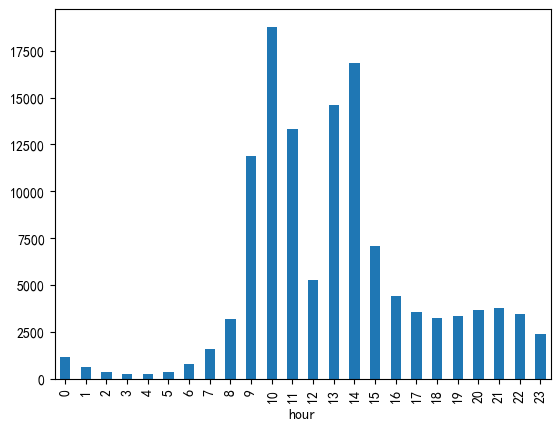

In [152]:
# 绘制hour_counts的柱状图:plot(kind = "bar")
hour_counts.plot(kind = "bar")


In [ ]:
comments.head()

groupby

这里我们引入groupby函数来实现相似的功能。之前我们尝试使用max或mean函数对序列进行汇总，求最大值或均值，这些都是求全局汇总运算。然而，要更深入地研究数据，简单的聚合汇总通常是不够的。groupby操作允许您快速而有效地计算数据子集上的聚合。groupby聚合运算参见下图，参考资料《Python Data Science Handbook》，作者Jake VanderPlas。

<img src="../img/groupby.png" align='left' height="300" width="400"/>

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [159]:
# I will load the data titanic.csv and assign it to variable titanic. 
titanic = pd.read_csv("titanic.csv")

In [161]:
# group the data  titanic according to Pclass 
titanic_grouped = titanic.groupby("Pclass")

In [162]:
# visulize the average survived rates for each class.
titanic_grouped["Survived"].mean().plot(kind = "bar")

<Axes: xlabel='Pclass'>

In [163]:
for (pclass,group) in titanic_grouped:
    print(pclass)
    print(type(group))
    print(group.values)

1
<class 'pandas.core.frame.DataFrame'>
[[1 1 'Mrs. John Bradley (Florence Briggs Thayer) Cumings' ... 1 0
  71.2833]
 [1 1 'Mrs. Jacques Heath (Lily May Peel) Futrelle' ... 1 0 53.1]
 [0 1 'Mr. Timothy J McCarthy' ... 0 0 51.8625]
 ...
 [1 1 'Mrs. Thomas Jr (Lily Alexenia Wilson) Potter' ... 0 1 83.1583]
 [1 1 'Miss. Margaret Edith Graham' ... 0 0 30.0]
 [1 1 'Mr. Karl Howell Behr' ... 0 0 30.0]]
2
<class 'pandas.core.frame.DataFrame'>
[[1 2 'Mrs. Nicholas (Adele Achem) Nasser' ... 1 0 30.0708]
 [1 2 'Mrs. (Mary D Kingcome) Hewlett' ... 0 0 16.0]
 [1 2 'Mr. Charles Eugene Williams' ... 0 0 13.0]
 ...
 [1 2 'Mrs. William (Imanita Parrish Hall) Shelley' ... 0 1 26.0]
 [0 2 'Mr. Frederick James Banfield' ... 0 0 10.5]
 [0 2 'Rev. Juozas Montvila' ... 0 0 13.0]]
3
<class 'pandas.core.frame.DataFrame'>
[[0 3 'Mr. Owen Harris Braund' ... 1 0 7.25]
 [1 3 'Miss. Laina Heikkinen' ... 0 0 7.925]
 [0 3 'Mr. William Henry Allen' ... 0 0 8.05]
 ...
 [0 3 'Mrs. William (Margaret Norton) Rice' ... 0

## which hour people make comments actively?

- use groupby function to group the data according to hour
- visulize the average number of comments for each hour
- which hour people make comments actively?

In [165]:
# Sort group keys. Groupby preserves the order of rows within each group.
comments_group_by_hour = comments.groupby("hour")
comments_group_by_hour

In [166]:
# The GroupBy object is a very flexible abstraction. 
# you can simply treat it as if it’s a collection of DataFrames
for (hour,group) in comments_group_by_hour:
    print(hour)
    print(group.shape)

0
(1165, 6)
1
(627, 6)
2
(351, 6)
3
(237, 6)
4
(235, 6)
5
(341, 6)
6
(806, 6)
7
(1561, 6)
8
(3202, 6)
9
(11891, 6)
10
(18776, 6)
11
(13338, 6)
12
(5275, 6)
13
(14596, 6)
14
(16844, 6)
15
(7097, 6)
16
(4428, 6)
17
(3536, 6)
18
(3239, 6)
19
(3338, 6)
20
(3641, 6)
21
(3755, 6)
22
(3448, 6)
23
(2399, 6)


In [167]:
# 对于分组的某个序列进行汇总预算，这里仅仅是计数：aggregate(np.count_nonzero)
import numpy as np
grouped_hour = comments_group_by_hour.aggregate(np.count_nonzero)
grouped_hour

,modified_date,comment,author,dayofweek,month
hour,,,,,
0,1165,1165,1165,1165,1165
1,627,627,627,627,627
2,351,351,351,351,351
3,237,237,237,237,237
4,235,235,235,235,235
5,341,341,341,341,341
6,806,806,806,806,806
7,1561,1561,1561,1561,1561
8,3202,3202,3202,3202,3202


In [168]:
grouped_hour.comment.plot(kind="bar")

<Axes: xlabel='hour'>

we can do it with groupby in another way

In [169]:
# group the comments by index date hour and counts each group
comments_by_hour = comments.groupby(["hour"])["hour"].count()
# plot comments_by_hour
comments_by_hour.plot(kind = "bar")

<Axes: xlabel='hour'>

## group by dayofweek and hour

In [170]:
# 根据["dayofweek","hour"]进行分组, sort=True

comments_group_by_dayofweek_hour = comments.groupby(["dayofweek","hour"],sort=True)

In [171]:
# 在分组内统计评论个数:aggregate(np.count_nonzero)
grouped_dayofweek_hour = comments_group_by_dayofweek_hour.aggregate(np.count_nonzero)
grouped_dayofweek_hour


modified_date  comment  author  month
dayofweek hour                                       
1         0               133      133     133    133
          1                75       75      75     75
          2                35       35      35     35
          3                23       23      23     23
          4                21       21      21     21
...                       ...      ...     ...    ...
7         19              283      283     283    283
          20              305      305     305    305
          21              359      359     359    359
          22              283      283     283    283
          23              250      250     250    250

[168 rows x 4 columns]

In [172]:
# 查看grouped_dayofweek_hour的index，这是MultiIndex
# unstack() 方法将DataFrame或Series中的索引级别"旋转"到列，从而改变数据的形状。它是 stack() 方法的逆操作。
grouped_dayofweek_hour.comment.unstack()

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dayofweek,,,,,,,,,,,,,,,,,,,,,
1,133,75,35,23,21,29,107,214,434,2382,...,3001,277,301,319,311,323,367,412,424,291
2,176,94,51,33,39,75,138,271,547,2029,...,3218,1279,806,606,540,570,682,631,537,390
3,159,97,47,42,54,59,132,270,546,2161,...,3238,1202,706,546,473,503,560,589,554,425
4,217,117,66,42,40,52,153,245,590,2263,...,3402,1346,802,618,607,597,617,646,622,359
5,181,91,79,45,40,69,131,293,621,2360,...,3368,1413,822,654,589,589,634,639,592,403
6,160,79,43,33,30,31,79,144,229,388,...,336,1246,688,548,461,473,476,479,436,281
7,139,74,30,19,11,26,66,124,235,308,...,281,334,303,245,258,283,305,359,283,250


In [ ]:
# 使用unstack函数将最内层的行索引还原成了列索引
unstack_grouped_dayofweek_hour = grouped_dayofweek_hour.comment.unstack()
unstack_grouped_dayofweek_hour

In [ ]:
unstack_grouped_dayofweek_hour.T.plot(kind="bar")

In [ ]:
import matplotlib.pyplot as plt
# IPython提供的一个有趣的后端是inline。有了这个后端，绘图命令的输出在前端显示，
# 就像Jupyter笔记本一样，直接显示在生成它的代码单元的下面。
%matplotlib inline

In [ ]:
grouped_dayofweek_hour_unstack = grouped_dayofweek_hour.comment.unstack()
grouped_dayofweek_hour_unstack

In [ ]:
# 构建一个多子图，4行1列，共享x轴
fig, ax = plt.subplots(4,1,sharex=True)


grouped_dayofweek_hour_unstack.iloc[0,:].plot(kind='bar',ax=ax[0])

# 将周1-周6的评论数可视化


<font color=blue face=雅黑>思考：大家分析上图能够发现什么规律呢？</font>

# 本周课后学习安排

- 个人项目改进：

      - 1. 文献个人项目相关的文献，做文献综述。个人项目的报告包含（“相关研究”）一节
      - 2. 研究方法学习，并基于研究方法学习改进研究设计（之前开题报告的一部分）


**本周没有需要提交的作业**

**下周邀请同学分享文献调研、研究设计改进、研究方法学习**